In [1]:
import os
import numpy as np
from pydicom import dcmread
import matplotlib.pyplot as plt
from mpl_interactions import ipyplot as iplt

%matplotlib ipympl

In [2]:
data_dir = './data'

slices = []

for i in range(len(os.listdir(data_dir))):
    filepath = os.path.join(data_dir, f'VHMCT1mm-Head ({i + 1}).dcm')
    ds = dcmread(filepath)
    slices.append(ds.pixel_array)

image3d = np.stack(slices)

print(image3d.shape)

(245, 512, 512)


In [3]:
def slice_image(z, axis=0):
    z1 = int(np.floor(z))
    z2 = int(np.ceil(z))
    t = (z - z1) / (z2 - z1) if z2 > z1 else 0
    return image3d.take(z1, axis=axis) * (1 - t) +  image3d.take(z2, axis=axis) * t

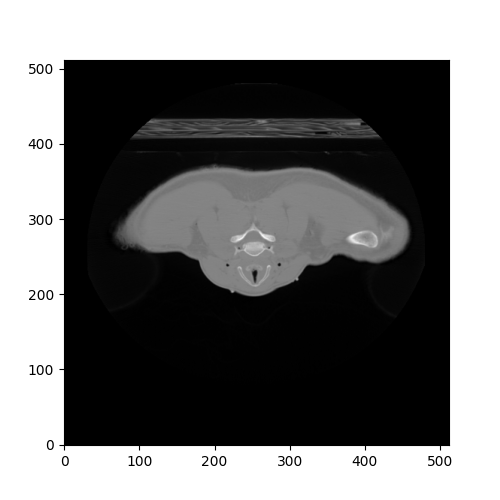

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
controls = iplt.imshow(slice_image, z=(0, image3d.shape[0] - 1), axis=0, origin='lower', cmap='gray')

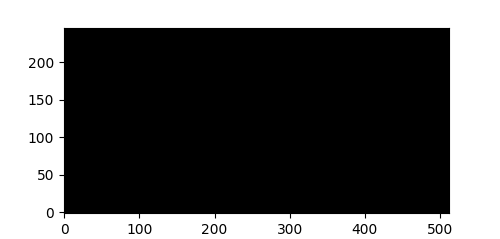

In [5]:
fig, ax = plt.subplots(figsize=(5, 5 * image3d.shape[0] / image3d.shape[2]))
controls = iplt.imshow(slice_image, z=(0, image3d.shape[1] - 1), axis=1, origin='lower', cmap='gray')

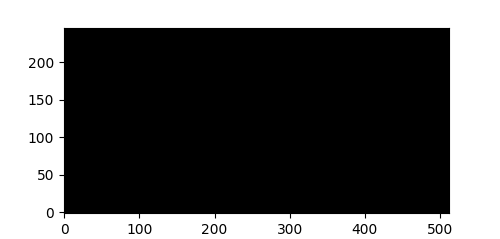

In [6]:
fig, ax = plt.subplots(figsize=(5, 5 * image3d.shape[0] / image3d.shape[1]))
controls = iplt.imshow(slice_image, z=(0, image3d.shape[2] - 1), axis=2,  origin='lower', cmap='gray')

In [7]:
# plt.close('all')